In [1]:
import os 
import glob as glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
data_file_paths = '/home/leoseen/aos_773/PS_4/Windsond_Data_Files'

In [39]:
class windsonde_data_information:
    def __init__(self, folder_path):
        self.date = os.path.basename(folder_path)
        raw_flight_paths = glob.glob(f'{folder_path}/*.raw_flight_history.csv')
        raw_data = {}
        clean_data = {}
        for raw_flight_path in raw_flight_paths:
            raw_flight_data = pd.read_csv(raw_flight_path)
            if np.max(raw_flight_data[' Altitude (m MSL)'])<1000:
                continue
            else:
                flight_number = os.path.basename(raw_flight_path).split('.')[0].split('_')[-1]
                raw_flight_data['time_s'] = pd.to_timedelta(raw_flight_data['UTC time']).dt.total_seconds().astype(int)
                raw_flight_data[' Speed (m/s)'] = raw_flight_data[' Speed (m/s)'].replace(r"^\s*$", np.nan, regex=True)
                raw_flight_data[' Heading (degrees)'] = raw_flight_data[' Heading (degrees)'].replace(r"^\s*$", np.nan, regex=True)
                raw_flight_data[' Speed (m/s)'] = raw_flight_data[' Speed (m/s)'].astype(float)
                raw_flight_data[' Heading (degrees)'] = raw_flight_data[' Heading (degrees)'].astype(float)
                raw_flight_data[' Temperature (K)'] = raw_flight_data[' Temperature (C)']+273.15
                
                raw_flight_data['SVP'] = 0.61078*1e3*np.exp((17.2694*(raw_flight_data[' Temperature (K)']-273.16))/(raw_flight_data[' Temperature (K)']-35.86))
                raw_flight_data['AVP'] = raw_flight_data[' Relative humidity (%)']*raw_flight_data['SVP']/100

                raw_flight_data['SWVMR'] = 0.622*(raw_flight_data['SVP']/(raw_flight_data[' Pressure (Pascal)']-raw_flight_data['SVP']))
                raw_flight_data['AWVMR'] = 0.622*(raw_flight_data['AVP']/(raw_flight_data[' Pressure (Pascal)']-raw_flight_data['AVP']))
                raw_flight_data['LWVMR'] = raw_flight_data['AWVMR'] - raw_flight_data['SWVMR']
                P_o = 100*1e3 # 100 kPa to pascals
                raw_flight_data['PT'] = (raw_flight_data[' Temperature (K)'])*(P_o/raw_flight_data[' Pressure (Pascal)'])**0.286
                raw_flight_data['VPT'] = raw_flight_data['PT']*(1+0.61*raw_flight_data['SWVMR']-raw_flight_data['LWVMR'])

                raw_flight_data['DPT'] = ((243.04*np.log(raw_flight_data['AVP']/611.21))/(17.625-np.log(raw_flight_data['AVP']/611.21)))+273.15
                raw_data[flight_number] = raw_flight_data

                clean_flight_data = self.get_clean_data(raw_flight_data)
                clean_data[flight_number] = clean_flight_data
                
        self.raw_data = raw_data
        self.clean_data = clean_data

    def get_clean_data(self, raw_data):
        diff_relative_starting_height = (raw_data[' Altitude (m AGL)']-raw_data[' Altitude (m AGL)'].iloc[0]).diff()
        bool_values = diff_relative_starting_height>0
        rolling_sum = bool_values.rolling(3).sum() == 3
        start_idx = rolling_sum.idxmax()-2
        clean_data = raw_data.iloc[start_idx:]
        clean_data['Height (m AGL)'] = clean_data[' Altitude (m AGL)']- clean_data[' Altitude (m AGL)'].iloc[0]
        clean_data['Time_al'] = clean_data['time_s'] - clean_data['time_s'].iloc[0]
        return clean_data

In [40]:
folder_paths = glob.glob(f'{data_file_paths}/*')
windsonde_data = {}
for folder_path in folder_paths:
    flight_date = os.path.basename(folder_path)
    windsonde_data[flight_date] = windsonde_data_information(folder_path)

/tmp/ipykernel_553/294307833.py:45: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean_data['Height (m AGL)'] = clean_data[' Altitude (m AGL)']- clean_data[' Altitude (m AGL)'].iloc[0]
/tmp/ipykernel_553/294307833.py:46: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean_data['Time_al'] = clean_data['time_s'] - clean_data['time_s'].iloc[0]


(0.0, 1255.8)

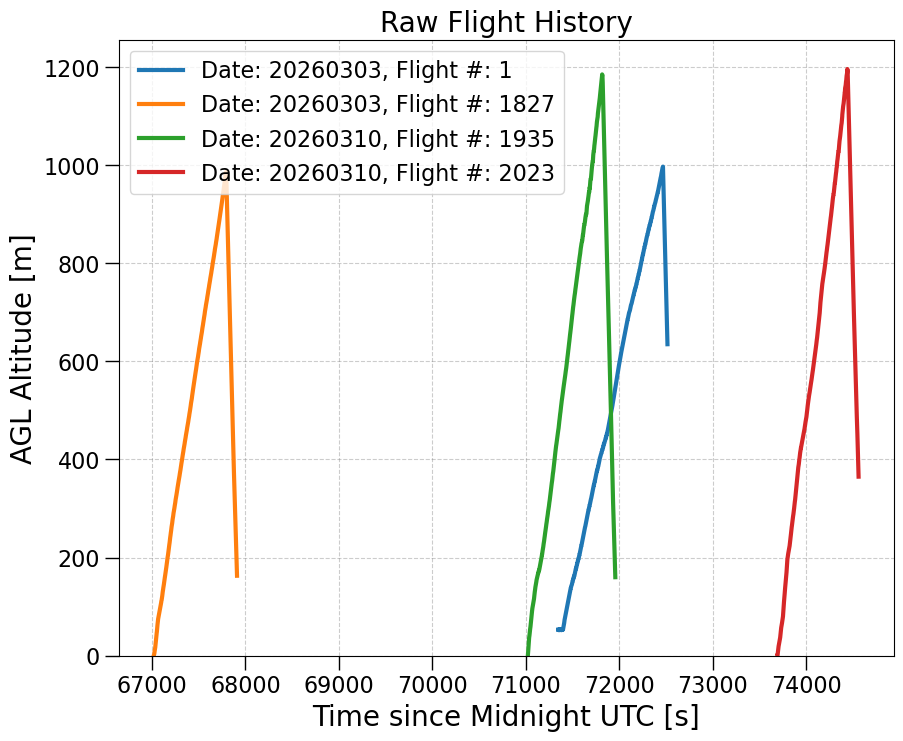

In [66]:
fig, ax = plt.subplots(1,1, figsize = (10,8))

for key, value in windsonde_data.items():
    for k, v in value.raw_data.items():
        ax.plot(v['time_s'], v[' Altitude (m AGL)'], label = f'Date: {key}, Flight #: {k}', linewidth = 3)

ax.set_title(f'Raw Flight History', fontsize = 20)
ax.set_xlabel(f'Time since Midnight UTC [s]', fontsize = 20)
ax.set_ylabel(f'AGL Altitude [m]', fontsize = 20)
ax.tick_params(axis = 'both', which = 'major', labelsize = 16, width = 1, length = 10)
ax.tick_params(axis = 'both', which = 'minor', labelsize = 16, width = 1, length = 4)
ax.grid(alpha = 0.4, color = 'grey', linestyle = '--')
ax.legend(fontsize = 16)
ax.set_ylim(bottom = 0)

(0.0, 1170.75)

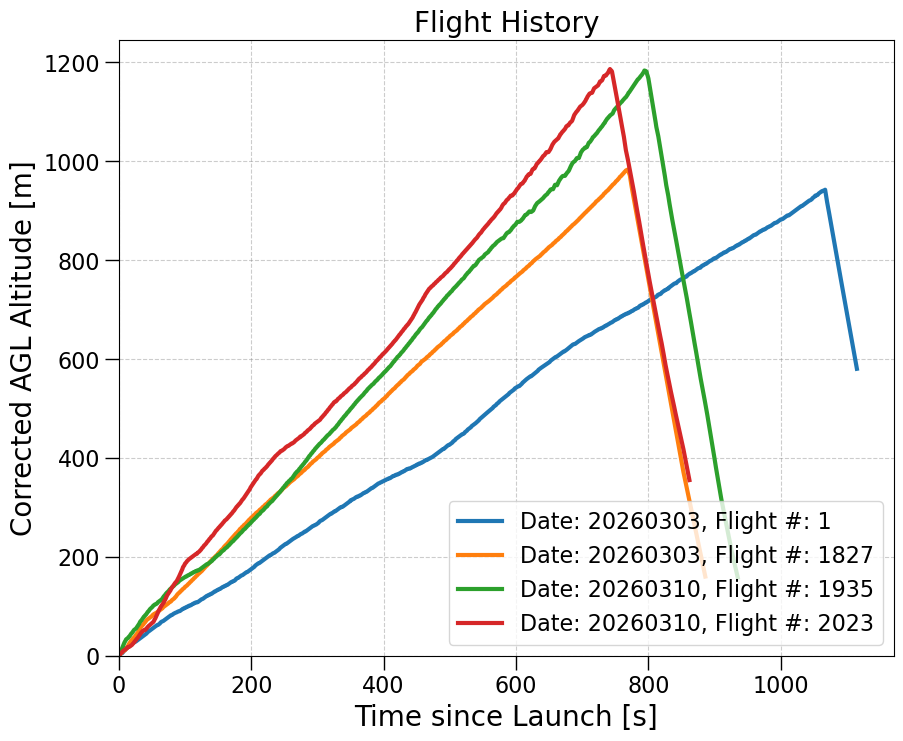

In [67]:
fig, ax = plt.subplots(1,1, figsize = (10,8))

for key, value in windsonde_data.items():
    for k, v in value.clean_data.items():
        ax.plot(v['Time_al'], v['Height (m AGL)'], label = f'Date: {key}, Flight #: {k}', linewidth = 3)

ax.set_title(f'Flight History', fontsize = 20)
ax.set_xlabel(f'Time since Launch [s]', fontsize = 20)
ax.set_ylabel(f'Corrected AGL Altitude [m]', fontsize = 20)
ax.tick_params(axis = 'both', which = 'major', labelsize = 16, width = 1, length = 10)
ax.tick_params(axis = 'both', which = 'minor', labelsize = 16, width = 1, length = 4)
ax.grid(alpha = 0.4, color = 'grey', linestyle = '--')
ax.legend(fontsize = 16)
ax.set_ylim(bottom = 0)
ax.set_xlim(left = 0)

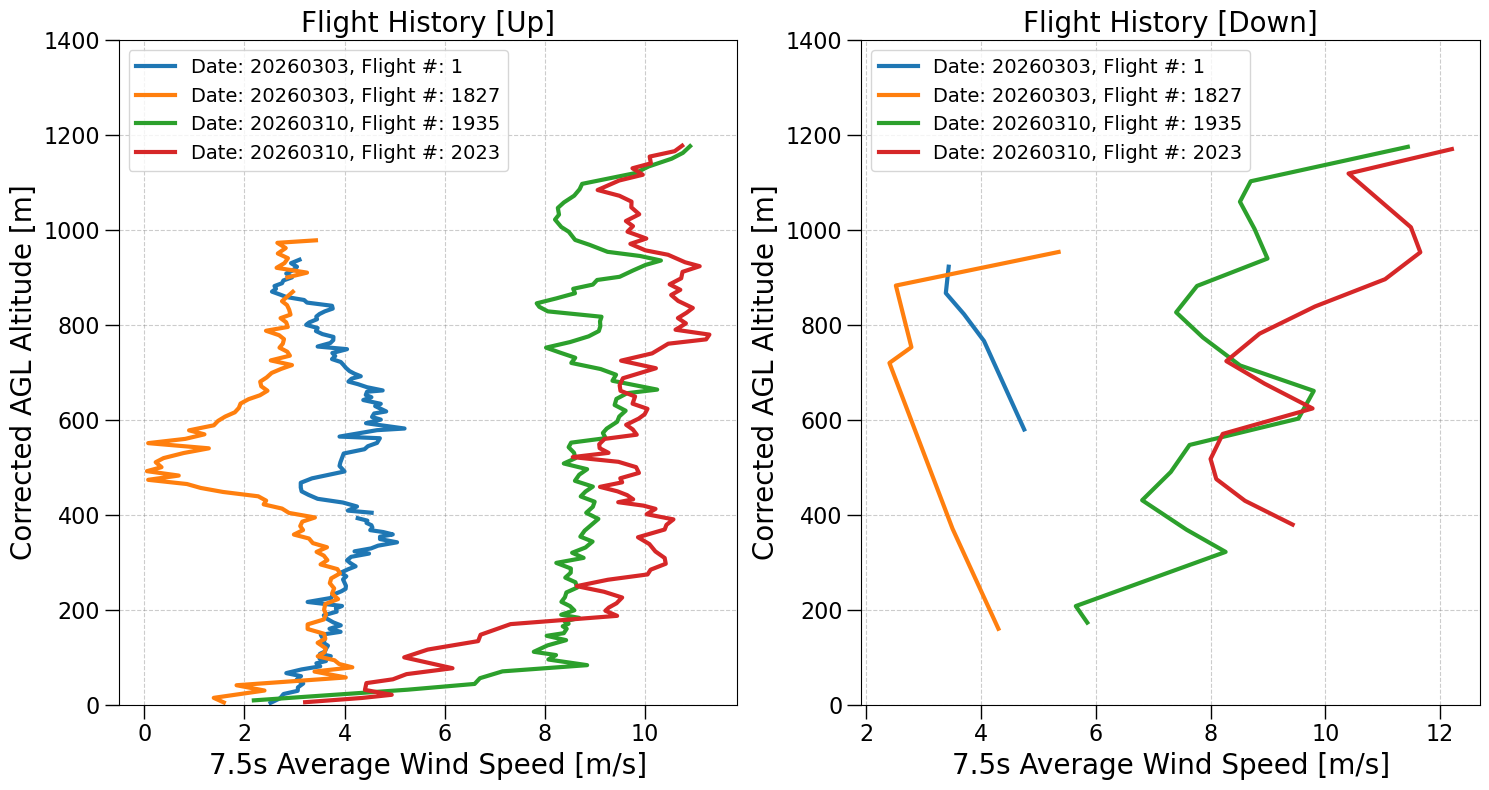

In [68]:
fig, ax = plt.subplots(1,2, figsize = (15,8))

for key, value in windsonde_data.items():
    for k, v in value.clean_data.items():
        average_data = v.groupby(((v['Time_al'] // 7.5) * 7.5).rename('time_bin')).mean()# numeric_only=True
        max_idx = average_data['Height (m AGL)'].idxmax()
        up_data = average_data.loc[:max_idx]
        down_data = average_data.loc[max_idx+1:]
        ax[0].plot(up_data[' Speed (m/s)'], up_data['Height (m AGL)'], label = f'Date: {key}, Flight #: {k}', linewidth = 3)
        ax[1].plot(down_data[' Speed (m/s)'], down_data['Height (m AGL)'], label = f'Date: {key}, Flight #: {k}', linewidth = 3)
        # ax.plot(v[' Temperature (C)'], v['Height (m AGL)'], label = f'Date: {key}, Flight #: {k}', linewidth = 3)

ax[0].set_title(f'Flight History [Up]', fontsize = 20)
ax[0].set_xlabel(r'7.5s Average Wind Speed [m/s]', fontsize = 20)
ax[0].set_ylabel(f'Corrected AGL Altitude [m]', fontsize = 20)
ax[0].tick_params(axis = 'both', which = 'major', labelsize = 16, width = 1, length = 10)
ax[0].tick_params(axis = 'both', which = 'minor', labelsize = 16, width = 1, length = 4)
ax[0].grid(alpha = 0.4, color = 'grey', linestyle = '--')
ax[0].legend(fontsize = 14, loc = 'upper left')
ax[0].set_ylim(bottom = 0, top = 1400)

ax[1].set_title(f'Flight History [Down]', fontsize = 20)
ax[1].set_xlabel(r'7.5s Average Wind Speed [m/s]', fontsize = 20)
ax[1].set_ylabel(f'Corrected AGL Altitude [m]', fontsize = 20)
ax[1].tick_params(axis = 'both', which = 'major', labelsize = 16, width = 1, length = 10)
ax[1].tick_params(axis = 'both', which = 'minor', labelsize = 16, width = 1, length = 4)
ax[1].grid(alpha = 0.4, color = 'grey', linestyle = '--')
ax[1].legend(fontsize = 14, loc = 'upper left')
ax[1].set_ylim(bottom = 0, top = 1400)
fig.tight_layout()

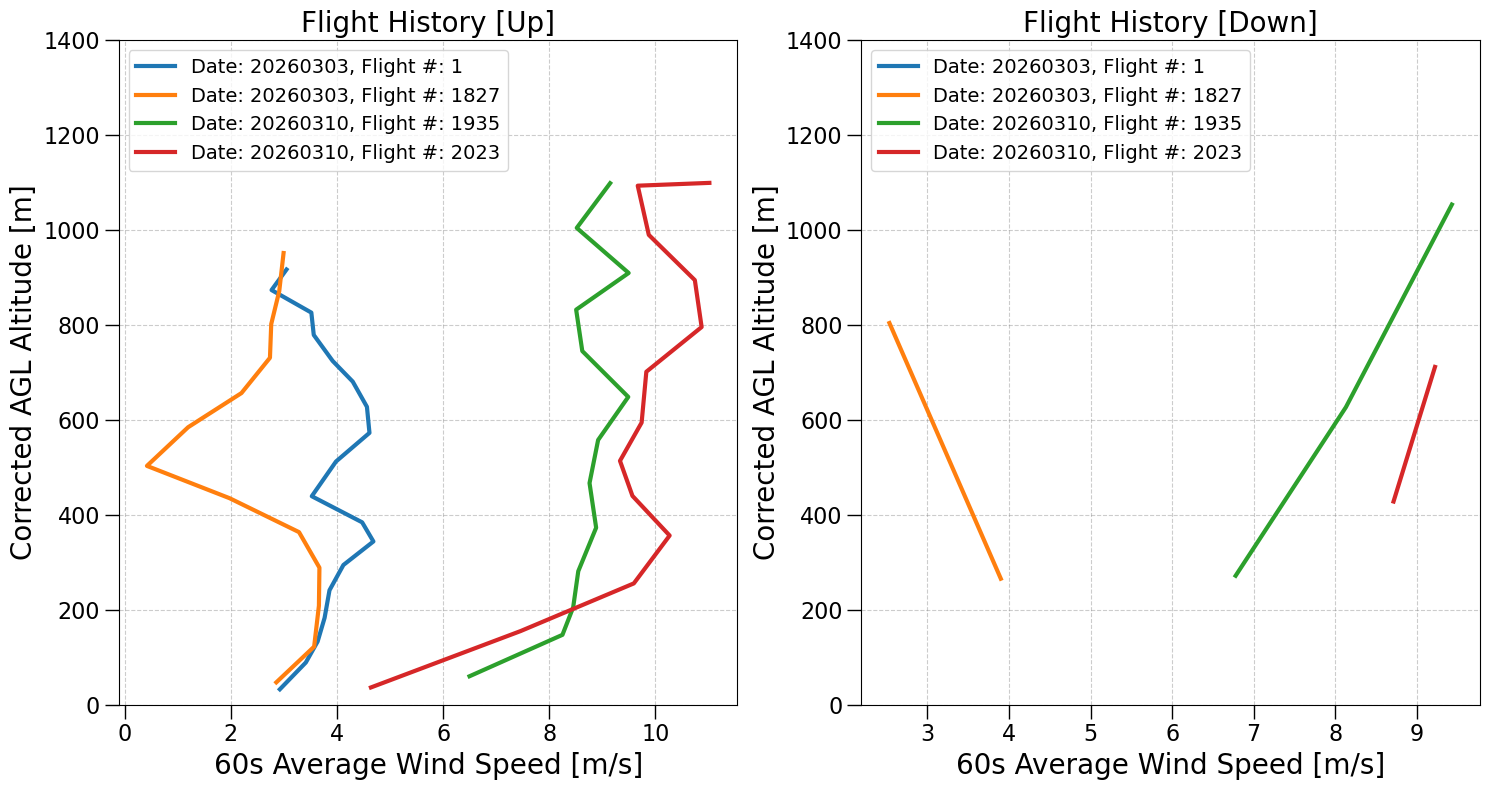

In [44]:
fig, ax = plt.subplots(1,2, figsize = (15,8))

for key, value in windsonde_data.items():
    for k, v in value.clean_data.items():
        average_data = v.groupby(((v['Time_al'] // 60) * 60).rename('time_bin')).mean()# numeric_only=True
        max_idx = average_data['Height (m AGL)'].idxmax()
        up_data = average_data.loc[:max_idx]
        down_data = average_data.loc[max_idx+1:]
        ax[0].plot(up_data[' Speed (m/s)'], up_data['Height (m AGL)'], label = f'Date: {key}, Flight #: {k}', linewidth = 3)
        ax[1].plot(down_data[' Speed (m/s)'], down_data['Height (m AGL)'], label = f'Date: {key}, Flight #: {k}', linewidth = 3)
        # ax.plot(v[' Temperature (C)'], v['Height (m AGL)'], label = f'Date: {key}, Flight #: {k}', linewidth = 3)

ax[0].set_title(f'Flight History [Up]', fontsize = 20)
ax[0].set_xlabel(r'60s Average Wind Speed [m/s]', fontsize = 20)
ax[0].set_ylabel(f'Corrected AGL Altitude [m]', fontsize = 20)
ax[0].tick_params(axis = 'both', which = 'major', labelsize = 16, width = 1, length = 10)
ax[0].tick_params(axis = 'both', which = 'minor', labelsize = 16, width = 1, length = 4)
ax[0].grid(alpha = 0.4, color = 'grey', linestyle = '--')
ax[0].legend(fontsize = 14, loc = 'upper left')
ax[0].set_ylim(bottom = 0, top = 1400)

ax[1].set_title(f'Flight History [Down]', fontsize = 20)
ax[1].set_xlabel(r'60s Average Wind Speed [m/s]', fontsize = 20)
ax[1].set_ylabel(f'Corrected AGL Altitude [m]', fontsize = 20)
ax[1].tick_params(axis = 'both', which = 'major', labelsize = 16, width = 1, length = 10)
ax[1].tick_params(axis = 'both', which = 'minor', labelsize = 16, width = 1, length = 4)
ax[1].grid(alpha = 0.4, color = 'grey', linestyle = '--')
ax[1].legend(fontsize = 14, loc = 'upper left')
ax[1].set_ylim(bottom = 0, top = 1400)
fig.tight_layout()

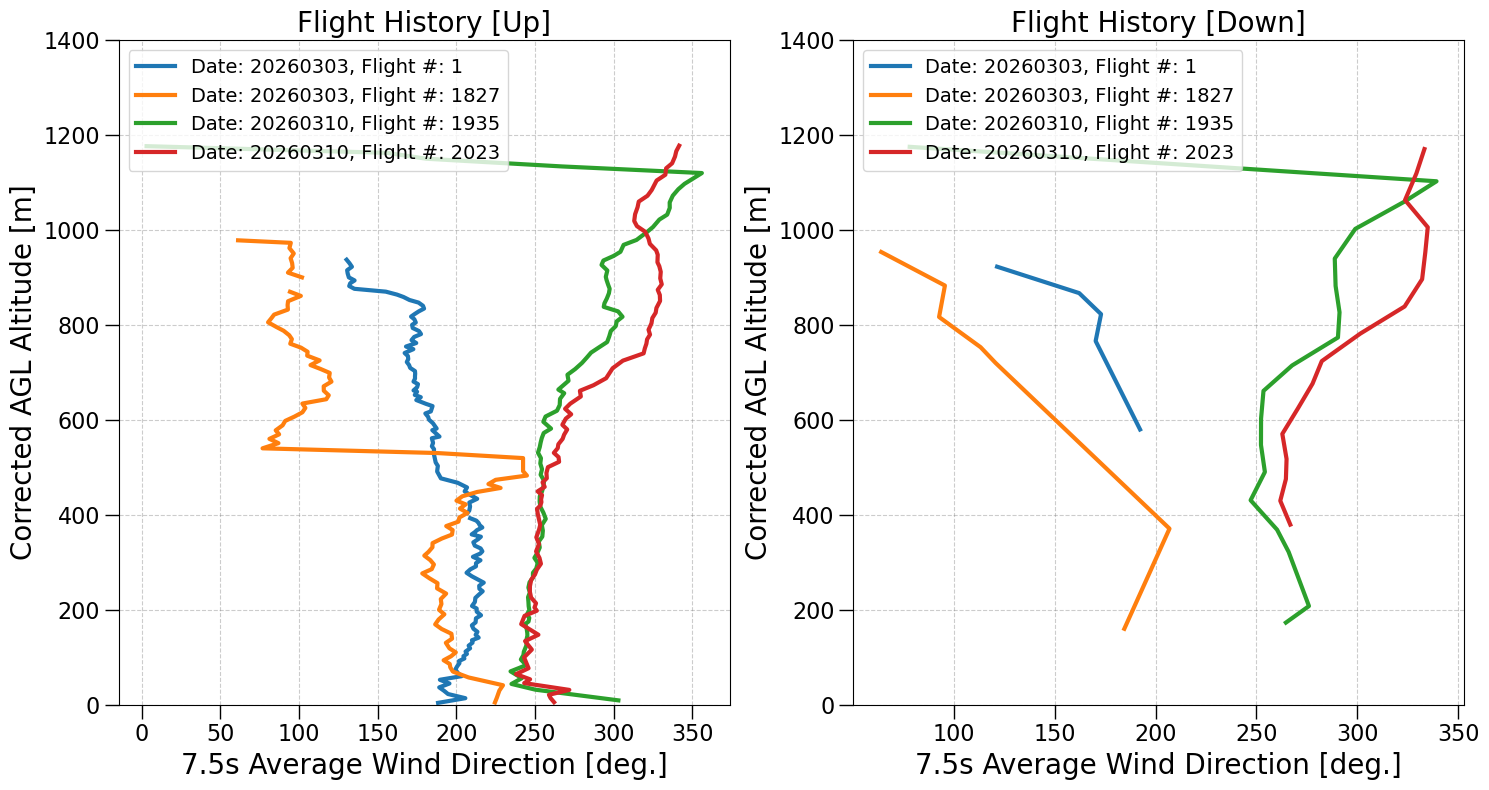

In [69]:
fig, ax = plt.subplots(1,2, figsize = (15,8))

for key, value in windsonde_data.items():
    for k, v in value.clean_data.items():
        average_data = v.groupby(((v['Time_al'] // 7.5) * 7.5).rename('time_bin')).mean()# numeric_only=True
        max_idx = average_data['Height (m AGL)'].idxmax()
        up_data = average_data.loc[:max_idx]
        down_data = average_data.loc[max_idx+1:]
        ax[0].plot(up_data[' Heading (degrees)'], up_data['Height (m AGL)'], label = f'Date: {key}, Flight #: {k}', linewidth = 3)
        ax[1].plot(down_data[' Heading (degrees)'], down_data['Height (m AGL)'], label = f'Date: {key}, Flight #: {k}', linewidth = 3)
        # ax.plot(v[' Temperature (C)'], v['Height (m AGL)'], label = f'Date: {key}, Flight #: {k}', linewidth = 3)

ax[0].set_title(f'Flight History [Up]', fontsize = 20)
ax[0].set_xlabel(r'7.5s Average Wind Direction [deg.]', fontsize = 20)
ax[0].set_ylabel(f'Corrected AGL Altitude [m]', fontsize = 20)
ax[0].tick_params(axis = 'both', which = 'major', labelsize = 16, width = 1, length = 10)
ax[0].tick_params(axis = 'both', which = 'minor', labelsize = 16, width = 1, length = 4)
ax[0].grid(alpha = 0.4, color = 'grey', linestyle = '--')
ax[0].legend(fontsize = 14, loc = 'upper left')
ax[0].set_ylim(bottom = 0, top = 1400)

ax[1].set_title(f'Flight History [Down]', fontsize = 20)
ax[1].set_xlabel(r'7.5s Average Wind Direction [deg.]', fontsize = 20)
ax[1].set_ylabel(f'Corrected AGL Altitude [m]', fontsize = 20)
ax[1].tick_params(axis = 'both', which = 'major', labelsize = 16, width = 1, length = 10)
ax[1].tick_params(axis = 'both', which = 'minor', labelsize = 16, width = 1, length = 4)
ax[1].grid(alpha = 0.4, color = 'grey', linestyle = '--')
ax[1].legend(fontsize = 14, loc = 'upper left')
ax[1].set_ylim(bottom = 0, top = 1400)
fig.tight_layout()

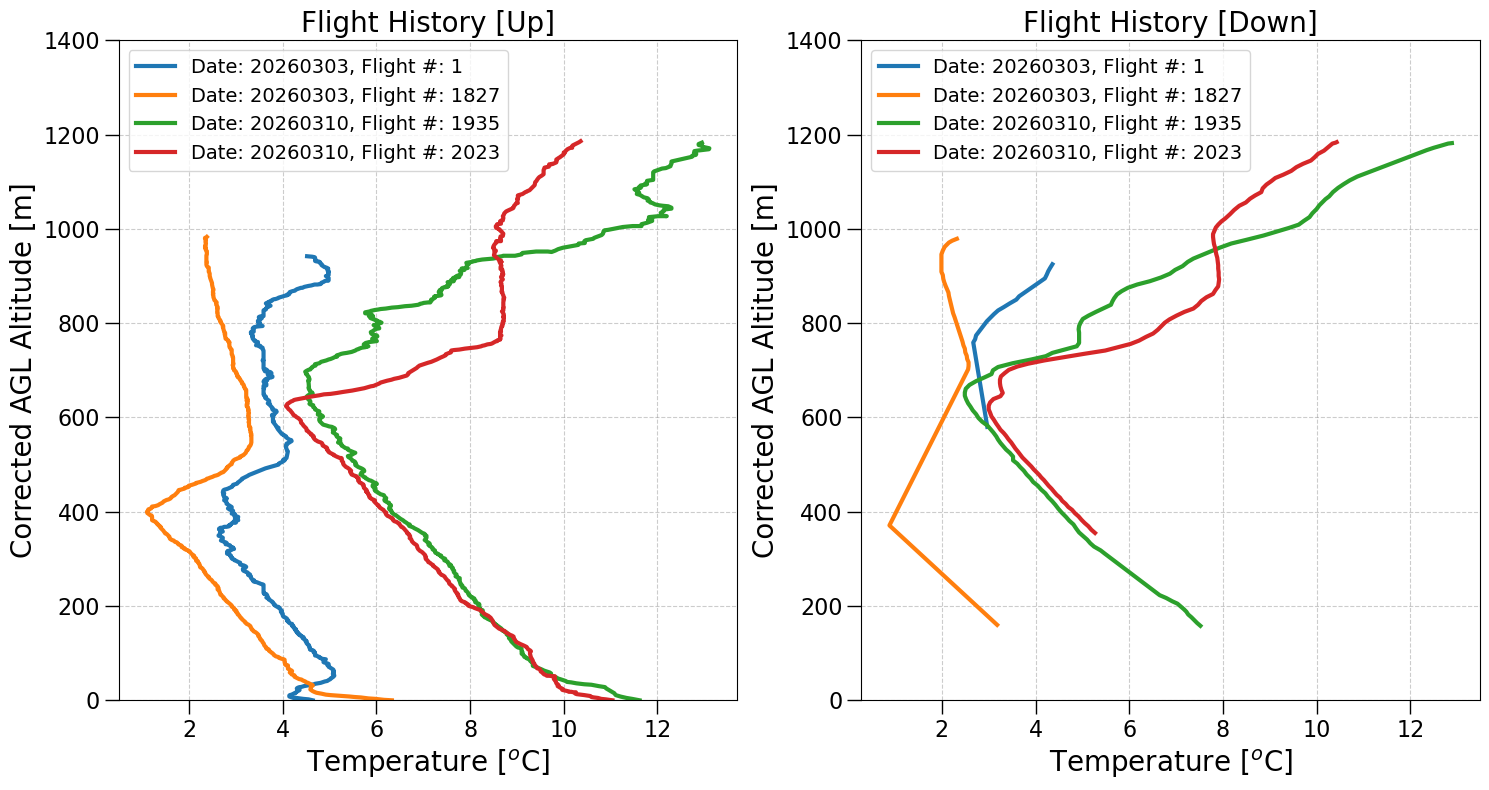

In [70]:
fig, ax = plt.subplots(1,2, figsize = (15,8))

for key, value in windsonde_data.items():
    for k, v in value.clean_data.items():
        max_idx = v['Height (m AGL)'].idxmax()
        up_data = v.loc[:max_idx]
        down_data = v.loc[max_idx+1:]
        ax[0].plot(up_data[' Temperature (C)'], up_data['Height (m AGL)'], label = f'Date: {key}, Flight #: {k}', linewidth = 3)
        ax[1].plot(down_data[' Temperature (C)'], down_data['Height (m AGL)'], label = f'Date: {key}, Flight #: {k}', linewidth = 3)
        # ax.plot(v[' Temperature (C)'], v['Height (m AGL)'], label = f'Date: {key}, Flight #: {k}', linewidth = 3)

ax[0].set_title(f'Flight History [Up]', fontsize = 20)
ax[0].set_xlabel(r'Temperature [${}^o$C]', fontsize = 20)
ax[0].set_ylabel(f'Corrected AGL Altitude [m]', fontsize = 20)
ax[0].tick_params(axis = 'both', which = 'major', labelsize = 16, width = 1, length = 10)
ax[0].tick_params(axis = 'both', which = 'minor', labelsize = 16, width = 1, length = 4)
ax[0].grid(alpha = 0.4, color = 'grey', linestyle = '--')
ax[0].legend(fontsize = 14, loc = 'upper left')
ax[0].set_ylim(bottom = 0, top = 1400)

ax[1].set_title(f'Flight History [Down]', fontsize = 20)
ax[1].set_xlabel(r'Temperature [${}^o$C]', fontsize = 20)
ax[1].set_ylabel(f'Corrected AGL Altitude [m]', fontsize = 20)
ax[1].tick_params(axis = 'both', which = 'major', labelsize = 16, width = 1, length = 10)
ax[1].tick_params(axis = 'both', which = 'minor', labelsize = 16, width = 1, length = 4)
ax[1].grid(alpha = 0.4, color = 'grey', linestyle = '--')
ax[1].legend(fontsize = 14, loc = 'upper left')
ax[1].set_ylim(bottom = 0, top = 1400)
fig.tight_layout()

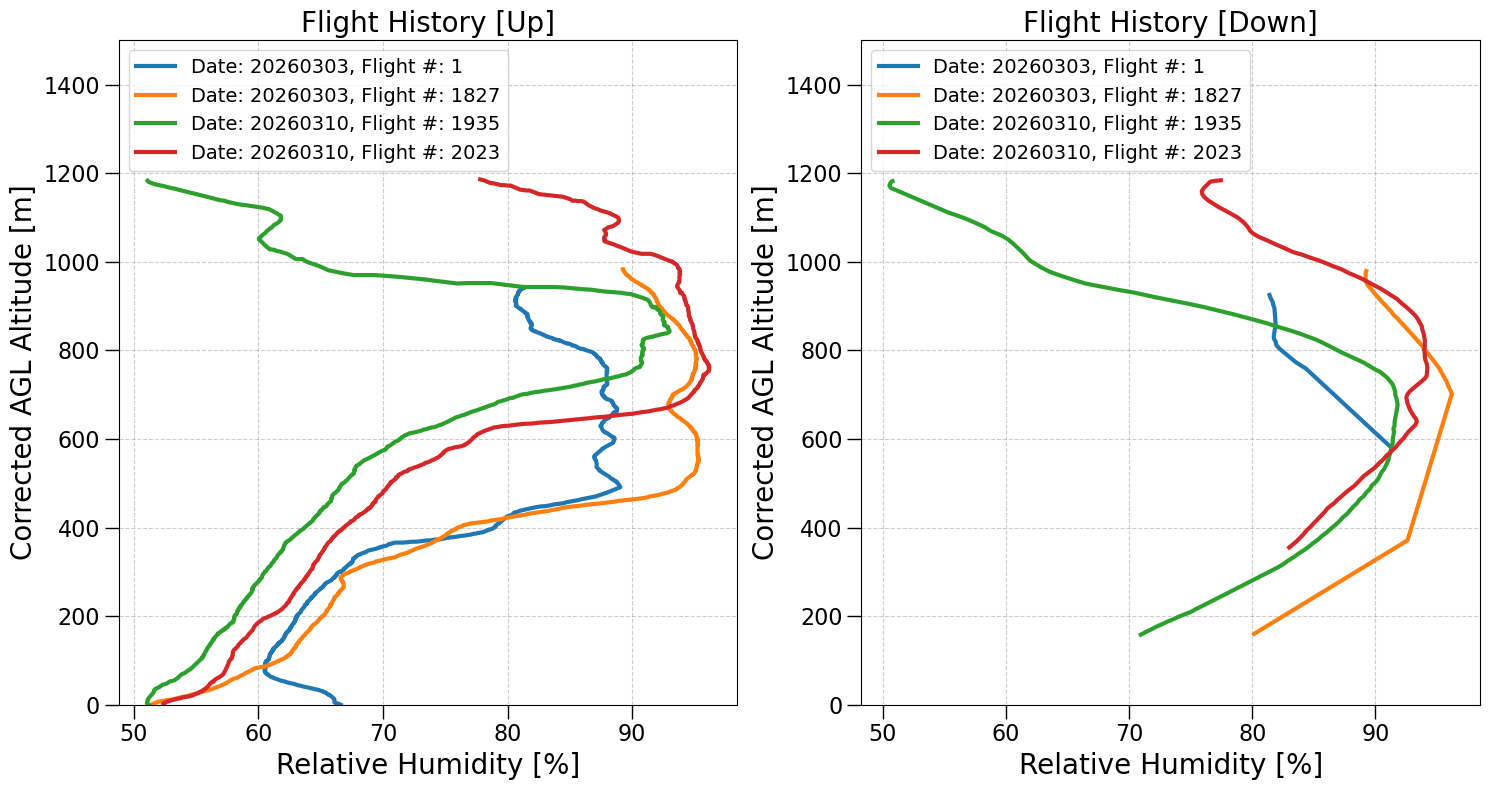

In [71]:
fig, ax = plt.subplots(1,2, figsize = (15,8))

for key, value in windsonde_data.items():
    for k, v in value.clean_data.items():
        max_idx = v['Height (m AGL)'].idxmax()
        up_data = v.loc[:max_idx]
        down_data = v.loc[max_idx+1:]
        ax[0].plot(up_data[' Relative humidity (%)'], up_data['Height (m AGL)'], label = f'Date: {key}, Flight #: {k}', linewidth = 3)
        ax[1].plot(down_data[' Relative humidity (%)'], down_data['Height (m AGL)'], label = f'Date: {key}, Flight #: {k}', linewidth = 3)
        # ax.plot(v[' Temperature (C)'], v['Height (m AGL)'], label = f'Date: {key}, Flight #: {k}', linewidth = 3)

ax[0].set_title(f'Flight History [Up]', fontsize = 20)
ax[0].set_xlabel(r'Relative Humidity [%]', fontsize = 20)
ax[0].set_ylabel(f'Corrected AGL Altitude [m]', fontsize = 20)
ax[0].tick_params(axis = 'both', which = 'major', labelsize = 16, width = 1, length = 10)
ax[0].tick_params(axis = 'both', which = 'minor', labelsize = 16, width = 1, length = 4)
ax[0].grid(alpha = 0.4, color = 'grey', linestyle = '--')
ax[0].legend(fontsize = 14, loc = 'upper left')
ax[0].set_ylim(bottom = 0, top = 1500)

ax[1].set_title(f'Flight History [Down]', fontsize = 20)
ax[1].set_xlabel(r'Relative Humidity [%]', fontsize = 20)
ax[1].set_ylabel(f'Corrected AGL Altitude [m]', fontsize = 20)
ax[1].tick_params(axis = 'both', which = 'major', labelsize = 16, width = 1, length = 10)
ax[1].tick_params(axis = 'both', which = 'minor', labelsize = 16, width = 1, length = 4)
ax[1].grid(alpha = 0.4, color = 'grey', linestyle = '--')
ax[1].legend(fontsize = 14, loc = 'upper left')
ax[1].set_ylim(bottom = 0, top = 1500)
fig.tight_layout()

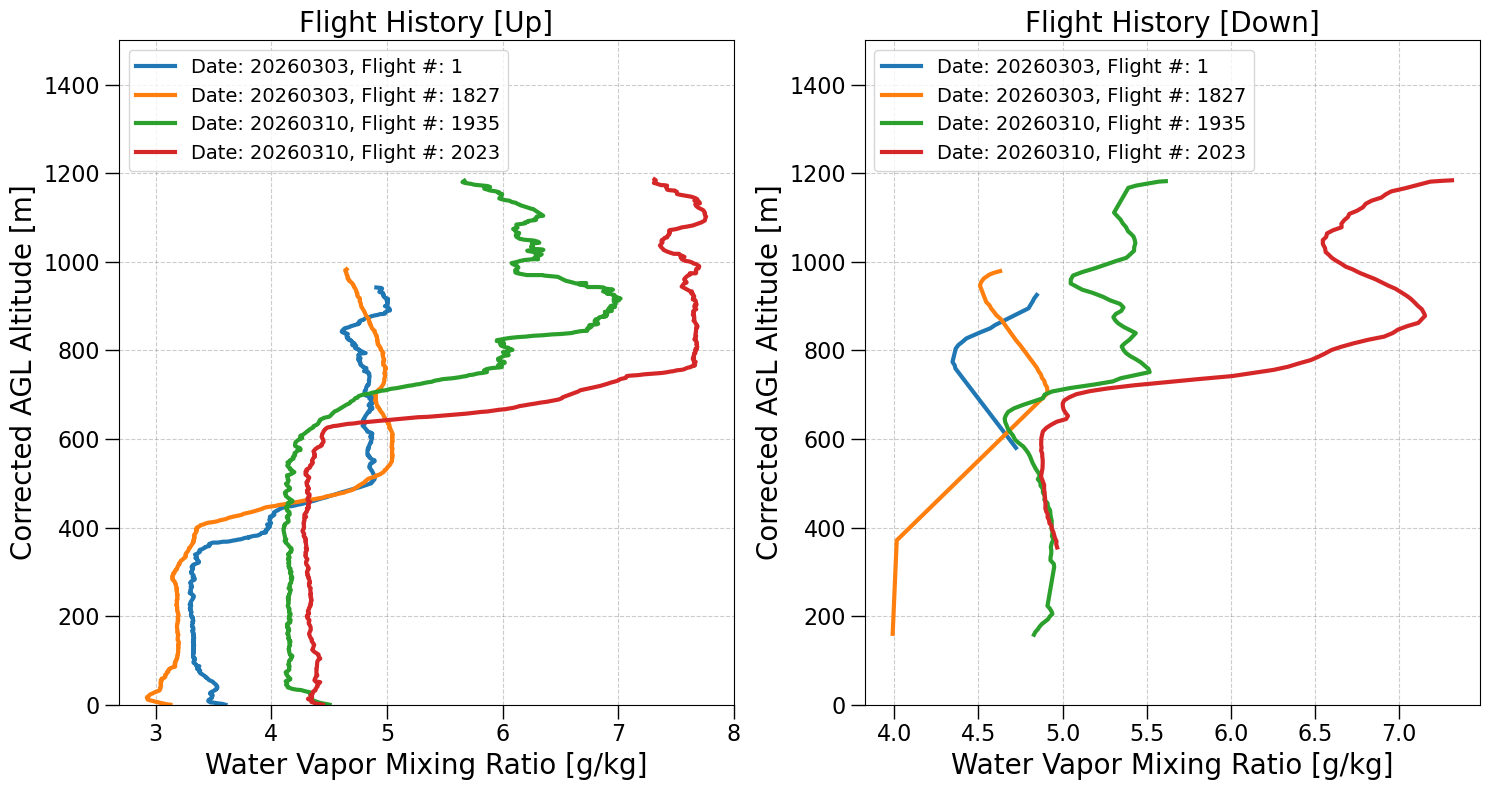

In [17]:
fig, ax = plt.subplots(1,2, figsize = (15,8))

for key, value in windsonde_data.items():
    for k, v in value.clean_data.items():
        max_idx = v['Height (m AGL)'].idxmax()
        up_data = v.loc[:max_idx]
        down_data = v.loc[max_idx+1:]
        ax[0].plot(up_data['AWVMR']*1e3, up_data['Height (m AGL)'], label = f'Date: {key}, Flight #: {k}', linewidth = 3)
        ax[1].plot(down_data['AWVMR']*1e3, down_data['Height (m AGL)'], label = f'Date: {key}, Flight #: {k}', linewidth = 3)
        # ax.plot(v[' Temperature (C)'], v['Height (m AGL)'], label = f'Date: {key}, Flight #: {k}', linewidth = 3)

ax[0].set_title(f'Flight History [Up]', fontsize = 20)
ax[0].set_xlabel(r'Water Vapor Mixing Ratio [g/kg]', fontsize = 20)
ax[0].set_ylabel(f'Corrected AGL Altitude [m]', fontsize = 20)
ax[0].tick_params(axis = 'both', which = 'major', labelsize = 16, width = 1, length = 10)
ax[0].tick_params(axis = 'both', which = 'minor', labelsize = 16, width = 1, length = 4)
ax[0].grid(alpha = 0.4, color = 'grey', linestyle = '--')
ax[0].legend(fontsize = 14, loc = 'upper left')
ax[0].set_ylim(bottom = 0, top = 1500)

ax[1].set_title(f'Flight History [Down]', fontsize = 20)
ax[1].set_xlabel(r'Water Vapor Mixing Ratio [g/kg]', fontsize = 20)
ax[1].set_ylabel(f'Corrected AGL Altitude [m]', fontsize = 20)
ax[1].tick_params(axis = 'both', which = 'major', labelsize = 16, width = 1, length = 10)
ax[1].tick_params(axis = 'both', which = 'minor', labelsize = 16, width = 1, length = 4)
ax[1].grid(alpha = 0.4, color = 'grey', linestyle = '--')
ax[1].legend(fontsize = 14, loc = 'upper left')
ax[1].set_ylim(bottom = 0, top = 1500)
fig.tight_layout()

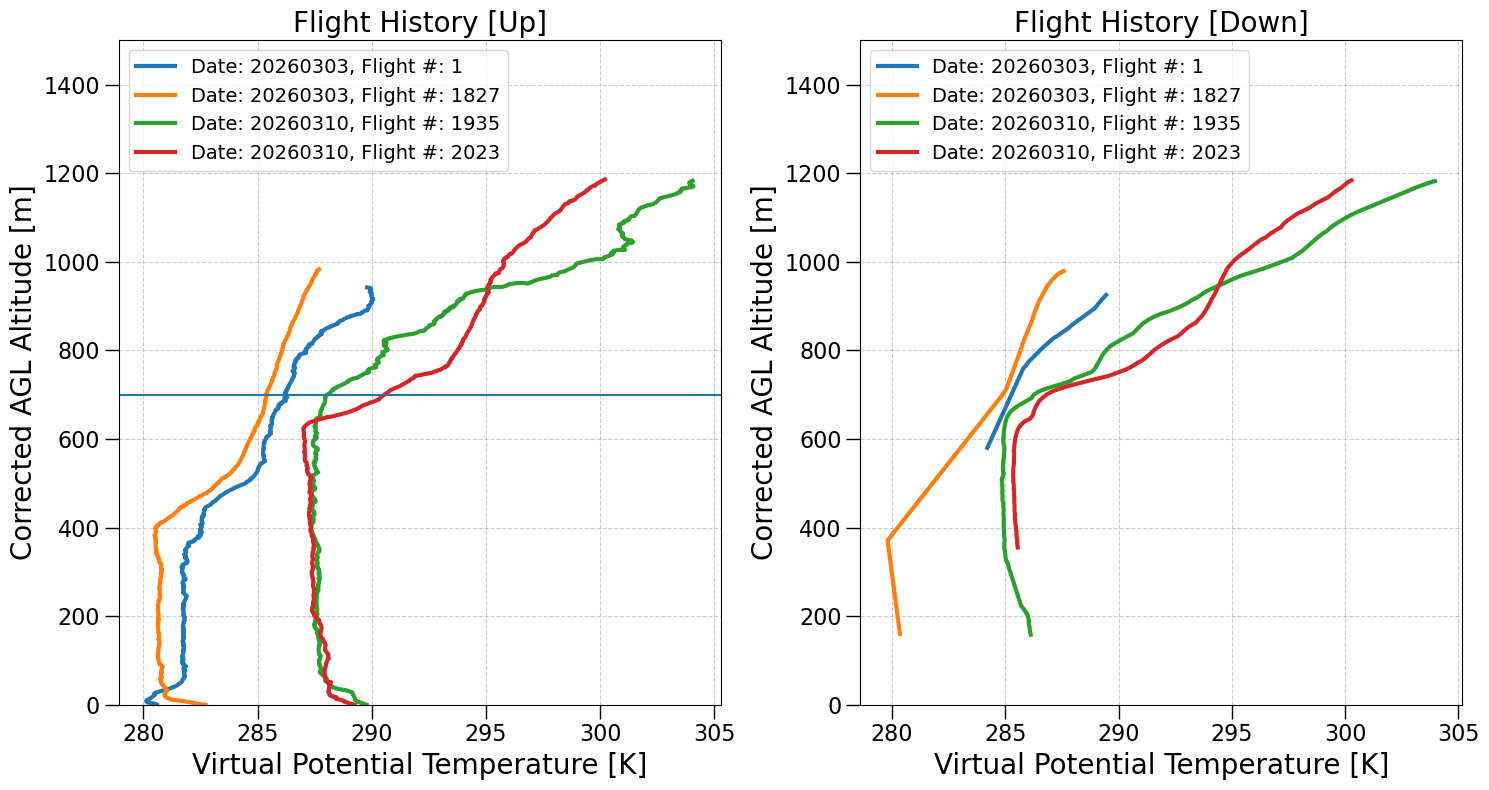

In [49]:
fig, ax = plt.subplots(1,2, figsize = (15,8))

for key, value in windsonde_data.items():
    for k, v in value.clean_data.items():
        max_idx = v['Height (m AGL)'].idxmax()
        up_data = v.loc[:max_idx]
        down_data = v.loc[max_idx+1:]
        ax[0].plot(up_data['VPT'], up_data['Height (m AGL)'], label = f'Date: {key}, Flight #: {k}', linewidth = 3)
        ax[1].plot(down_data['VPT'], down_data['Height (m AGL)'], label = f'Date: {key}, Flight #: {k}', linewidth = 3)
        # ax.plot(v[' Temperature (C)'], v['Height (m AGL)'], label = f'Date: {key}, Flight #: {k}', linewidth = 3)

ax[0].set_title(f'Flight History [Up]', fontsize = 20)
ax[0].set_xlabel(r'Virtual Potential Temperature [K]', fontsize = 20)
ax[0].set_ylabel(f'Corrected AGL Altitude [m]', fontsize = 20)
ax[0].tick_params(axis = 'both', which = 'major', labelsize = 16, width = 1, length = 10)
ax[0].tick_params(axis = 'both', which = 'minor', labelsize = 16, width = 1, length = 4)
ax[0].grid(alpha = 0.4, color = 'grey', linestyle = '--')
ax[0].legend(fontsize = 14, loc = 'upper left')
ax[0].set_ylim(bottom = 0, top = 1500)

ax[1].set_title(f'Flight History [Down]', fontsize = 20)
ax[1].set_xlabel(r'Virtual Potential Temperature [K]', fontsize = 20)
ax[1].set_ylabel(f'Corrected AGL Altitude [m]', fontsize = 20)
ax[1].tick_params(axis = 'both', which = 'major', labelsize = 16, width = 1, length = 10)
ax[1].tick_params(axis = 'both', which = 'minor', labelsize = 16, width = 1, length = 4)
ax[1].grid(alpha = 0.4, color = 'grey', linestyle = '--')
ax[1].legend(fontsize = 14, loc = 'upper left')
ax[1].set_ylim(bottom = 0, top = 1500)
fig.tight_layout()
ax[0].axhline(700)

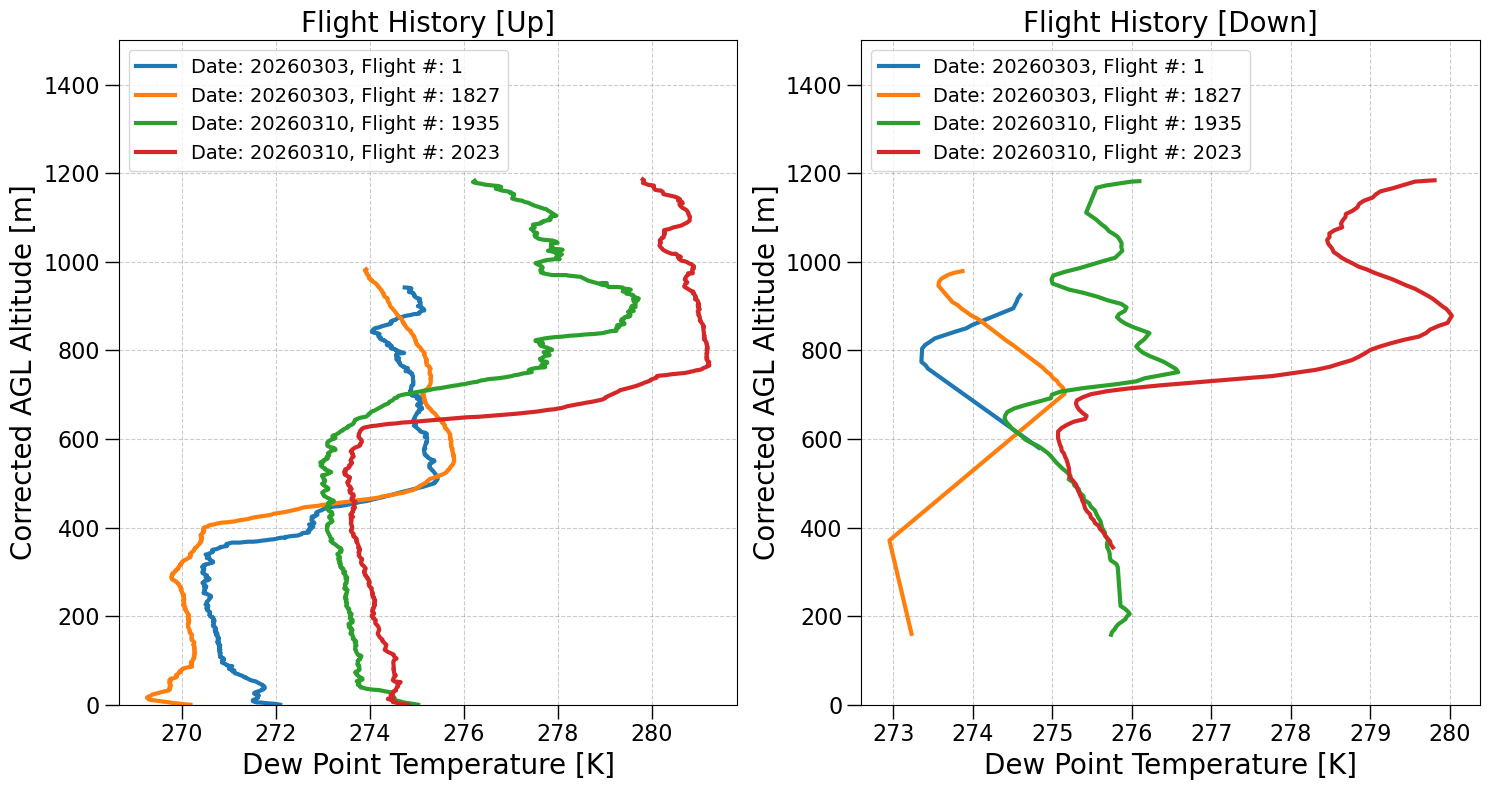

In [41]:
fig, ax = plt.subplots(1,2, figsize = (15,8))

for key, value in windsonde_data.items():
    for k, v in value.clean_data.items():
        max_idx = v['Height (m AGL)'].idxmax()
        up_data = v.loc[:max_idx]
        down_data = v.loc[max_idx+1:]
        ax[0].plot(up_data['DPT'], up_data['Height (m AGL)'], label = f'Date: {key}, Flight #: {k}', linewidth = 3)
        ax[1].plot(down_data['DPT'], down_data['Height (m AGL)'], label = f'Date: {key}, Flight #: {k}', linewidth = 3)
        # ax.plot(v[' Temperature (C)'], v['Height (m AGL)'], label = f'Date: {key}, Flight #: {k}', linewidth = 3)

ax[0].set_title(f'Flight History [Up]', fontsize = 20)
ax[0].set_xlabel(r'Dew Point Temperature [K]', fontsize = 20)
ax[0].set_ylabel(f'Corrected AGL Altitude [m]', fontsize = 20)
ax[0].tick_params(axis = 'both', which = 'major', labelsize = 16, width = 1, length = 10)
ax[0].tick_params(axis = 'both', which = 'minor', labelsize = 16, width = 1, length = 4)
ax[0].grid(alpha = 0.4, color = 'grey', linestyle = '--')
ax[0].legend(fontsize = 14, loc = 'upper left')
ax[0].set_ylim(bottom = 0, top = 1500)

ax[1].set_title(f'Flight History [Down]', fontsize = 20)
ax[1].set_xlabel(r'Dew Point Temperature [K]', fontsize = 20)
ax[1].set_ylabel(f'Corrected AGL Altitude [m]', fontsize = 20)
ax[1].tick_params(axis = 'both', which = 'major', labelsize = 16, width = 1, length = 10)
ax[1].tick_params(axis = 'both', which = 'minor', labelsize = 16, width = 1, length = 4)
ax[1].grid(alpha = 0.4, color = 'grey', linestyle = '--')
ax[1].legend(fontsize = 14, loc = 'upper left')
ax[1].set_ylim(bottom = 0, top = 1500)
fig.tight_layout()

# Testing

In [ ]:
windsonde_data['20260303'].clean_data['1'][-10:]

,UTC time,Altitude (m MSL),Altitude (m AGL),Pressure (Pascal),Speed (m/s),Heading (degrees),Temperature (C),Relative humidity (%),Internal temperature (C),Latitude,Longitude,Rise speed (m/s),time_s,Height (m AGL),Time_al
918,20:08:02,1160,897,88648,4.05,176.00,3.45,81.80,,,,-7.6,72482,842,1080
919,20:08:03,1152,889,88730,3.50,174.50,3.32,81.75,,,,-7.6,72483,834,1081
920,20:08:04,1145,882,88812,3.75,174.70,3.20,81.75,,43.053985,-89.432783,-7.5,72484,827,1082
921,20:08:05,1137,874,88894,3.75,170.30,3.11,81.90,,,,-7.5,72485,819,1083
922,20:08:06,1130,867,88976,3.70,174.40,3.04,81.95,,,,-7.5,72486,812,1084
923,20:08:07,1122,859,89058,3.45,167.80,2.96,82.20,,43.053888,-89.432770,-7.5,72487,804,1085
924,20:08:11,1092,829,89389,4.15,169.30,2.73,83.50,,,,-7.6,72491,774,1089
925,20:08:12,1084,821,89472,4.00,173.30,2.71,83.95,,,,-7.5,72492,766,1090
926,20:08:13,1077,814,89556,4.00,168.20,2.67,84.35,,43.053683,-89.432735,-7.6,72493,759,1091
927,20:08:37,898,635,91544,4.75,192.30,2.97,91.30,,43.052745,-89.432722,-7.5,72517,580,1115
